# 04 — Supervised Classification (Transfer Learning)

**Sentimentanalys av flygbolagstweets — steg 4/6**

Det här är huvudmodellen i projektet: vi tar DistilBERT och tränar den, med transfer
learning, att klassificera en tweet som **negative**, **neutral** eller **positive**.

Vi följer samma 7-stegsflöde för transfer learning som i tidigare kursmaterial — steg 1–5
här, steg 6 (utvärdering) i notebook 06, steg 7 (implementering) i Streamlit-appen:

1. Välj en passande pre-tränad modell
2. Förbered data *(gjort i notebook 01)*
3. Frys de tidiga lagren i modellen
4. Lägg till nya lager för vår specifika uppgift
5. Fine-tuning: träna om de sista lagren

> **Kräver internet + GPU:** kör i **Google Colab** (Runtime → Change runtime type → GPU).
> Med det nedsamplade datasetet tar hela träningen ca 5–10 minuter.


### Working directory

VS Code runs notebooks with the **notebook's own folder** as the working directory by
default, while Colab uses whichever folder you're in when you open it. The cell below
makes sure we always end up at the **project root**, so `data/`, `charts/`, and
`models/` land in the right place regardless of how you launched this notebook.


In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("Working directory:", os.getcwd())


Working directory: c:\Users\anoth\dev\AIkurs-statistik\airline-sentiment-transfer-learning


## Installation & imports

In [2]:
!pip install -q transformers tensorflow scikit-learn pandas matplotlib seaborn


In [3]:
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from transformers import DistilBertTokenizerFast, TFDistilBertModel

tf.random.set_seed(42)
np.random.seed(42)

os.makedirs("models", exist_ok=True)
print("GPU tillgänglig:", tf.config.list_physical_devices("GPU"))


c:\Users\anoth\dev\AIkurs-statistik\airline-sentiment-transfer-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



GPU tillgänglig: []


## Data

Läser in de färdiga train/val/test-filerna från **01_data_preparation.ipynb**.

In [4]:
train_df = pd.read_csv("data/train.csv", encoding="utf-8")
val_df = pd.read_csv("data/val.csv", encoding="utf-8")
test_df = pd.read_csv("data/test.csv", encoding="utf-8")

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)


Train: (2521, 4)  Val: (539, 4)  Test: (540, 4)


**Vad output visar:** bekräftar att alla tre filer laddats och har förväntad storlek
(ca 2520/540/540 rader). Om någon fil saknas får du ett `FileNotFoundError` — då behöver du
köra `01_data_preparation.ipynb` först, i samma Colab-session.


## Steg 1 — Välj en passande pre-tränad basmodell

Vi använder **DistilBERT** (`distilbert-base-uncased`):
- En destillerad (komprimerad) version av BERT: 6 transformer-lager (mot 12), ~66 miljoner
  parametrar (mot ~110 miljoner) — men behåller ca 97% av BERT:s språkförståelse och är
  ungefär 60% snabbare.
- Redan förtränad på en enorm mängd engelsk text, så den förstår redan grammatik och
  sammanhang — vi behöver bara lära den vårt specifika problem.

Ett perfekt val när målet är "kort & snabbt men väl utfört".


In [5]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64  # tweets är korta (median ~19 ord från notebook 02), 64 tokens räcker gott

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(texts):
    enc = tokenizer(
        list(texts), max_length=MAX_LEN, truncation=True, padding="max_length", return_tensors="tf"
    )
    return enc["input_ids"], enc["attention_mask"]

X_train_ids, X_train_mask = tokenize(train_df["text"])
X_val_ids, X_val_mask = tokenize(val_df["text"])
X_test_ids, X_test_mask = tokenize(test_df["text"])

y_train = train_df["airline_sentiment"].map(label2id).values
y_val = val_df["airline_sentiment"].map(label2id).values
y_test = test_df["airline_sentiment"].map(label2id).values


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


**Ingen synlig output här**, men cellen gör något viktigt: den omvandlar text till
siffror som modellen kan förstå. `X_train_ids` är en tabell där varje tweet blivit en rad av
64 tal (ett per token/ord-del), och `X_train_mask` markerar vilka av de 64 positionerna som
är riktig text vs. utfyllnad ("padding"). `y_train` är bara etiketterna omvandlade till
siffror (0=negative, 1=neutral, 2=positive) eftersom TensorFlow räknar med siffror, inte text.


## Steg 3 & 4 — Frys de tidiga lagren + lägg till egna lager

Vi laddar DistilBERT som en ren feature extractor (`TFDistilBertModel`) och bygger vår
egen klassificeringsarkitektur ovanpå:

- **Frysning:** hela DistilBERT-basen fryst till att börja med (`trainable = False`).
- **Egna lager:** `[CLS]`-representationen → `Dense(128, relu)` → `Dropout(0.3)` →
  `Dense(3, softmax)`.


In [6]:
bert_base = TFDistilBertModel.from_pretrained(MODEL_NAME, use_safetensors=False)
bert_base.trainable = False  # Steg 3: frys hela bas-modellen initialt

input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

bert_outputs = bert_base(input_ids, attention_mask=attention_mask)
cls_token = bert_outputs.last_hidden_state[:, 0, :]

# Steg 4: egna lager för vår specifika uppgift
x = tf.keras.layers.Dense(128, activation="relu")(cls_token)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(3, activation="softmax", name="sentiment_output")(x)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output, name="airline_sentiment_distilbert")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertModel: ['vocab_layer_norm', 'vocab_projector', 'vocab_transform', 'activation_13']
- This IS expected if you are initializing TFDistilBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFDistilBertModel were initialized from the model checkpoint at distilbert-base-uncased.
If your task is similar to the task the model of the checkpoint was

Model: "airline_sentiment_distilbert"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 64)]                 0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 64)]                 0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, 64, 768),   0          'attention_mask[0][0]']      
                              hidden_states=None, atten                

**Vad output visar:** `model.summary()` listar alla lager i modellen, deras
output-form och antal parametrar. Lägg märke till två saker: (1) `distilbert`-lagret har
~66 miljoner parametrar men de är **icke-tränbara** just nu (eftersom vi fryst basen) — de
syns under "Non-trainable params". (2) Våra egna lager (`dense`, `dropout`, `sentiment_output`)
har betydligt färre parametrar och är de enda som faktiskt uppdateras i nästa cell.


In [7]:
BATCH_SIZE = 32
EPOCHS_PHASE1 = 3

history1 = model.fit(
    x=[X_train_ids, X_train_mask], y=y_train,
    validation_data=([X_val_ids, X_val_mask], y_val),
    epochs=EPOCHS_PHASE1, batch_size=BATCH_SIZE,
    steps_per_epoch=math.ceil(len(y_train) / BATCH_SIZE),
    validation_steps=math.ceil(len(y_val) / BATCH_SIZE),
)


Epoch 1/3


79/79 [==============================] - 25s 292ms/step - loss: 0.8938 - accuracy: 0.6156 - val_loss: 0.7853 - val_accuracy: 0.6364
Epoch 2/3
79/79 [==============================] - 23s 289ms/step - loss: 0.7337 - accuracy: 0.6942 - val_loss: 0.6908 - val_accuracy: 0.7347
Epoch 3/3
79/79 [==============================] - 22s 285ms/step - loss: 0.6608 - accuracy: 0.7311 - val_loss: 0.6444 - val_accuracy: 0.7644


**Vad output visar:** en rad per epok med `loss`, `accuracy`, `val_loss` och
`val_accuracy`. `accuracy` är hur ofta modellen gissar rätt på träningsdatan, `val_accuracy`
är samma sak på valideringsdatan (som modellen inte tränat på). Eftersom bara våra egna,
små lager tränas i den här fasen är det normalt att accuracy stiger långsammare än den kommer
göra efter fine-tuning i nästa steg. Om `val_accuracy` är ungefär i linje med `accuracy`
(inte mycket lägre) betyder det att modellen inte överfittar ännu.


## Steg 5 — Fine-tuning: träna om de sista lagren

Vi låser upp de **två sista** transformerblocken i DistilBERT (av totalt 6) och tränar
vidare med en **mycket lägre learning rate**, så modellen kan finjustera sin språkförståelse
mot flygbolags-/kundtjänstspråk utan att förstöra det den redan lärt sig generellt.


In [8]:
bert_base.trainable = True
for layer in bert_base.distilbert.transformer.layer[:-2]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),  # lägre LR vid fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_PHASE2 = 2

history2 = model.fit(
    x=[X_train_ids, X_train_mask], y=y_train,
    validation_data=([X_val_ids, X_val_mask], y_val),
    epochs=EPOCHS_PHASE2, batch_size=BATCH_SIZE,
    steps_per_epoch=math.ceil(len(y_train) / BATCH_SIZE),
    validation_steps=math.ceil(len(y_val) / BATCH_SIZE),
)


Epoch 1/2
79/79 [==============================] - 65s 785ms/step - loss: 0.5433 - accuracy: 0.7802 - val_loss: 0.5092 - val_accuracy: 0.7848
Epoch 2/2
79/79 [==============================] - 69s 879ms/step - loss: 0.4538 - accuracy: 0.8211 - val_loss: 0.4959 - val_accuracy: 0.7941


**Vad output visar:** samma sorts träningslogg som innan, men nu bör `accuracy` och
`val_accuracy` stiga tydligare, eftersom modellen nu också får finjustera själva
språkförståelsen (de två sista transformerblocken) mot vårt specifika problem, inte bara
klassificeringshuvudet. Håll ögonen på om `val_loss` börjar **stiga** medan tränings-`loss`
fortsätter sjunka — det är ett tecken på överfittning, och då kan färre epoker eller mer
dropout behövas.


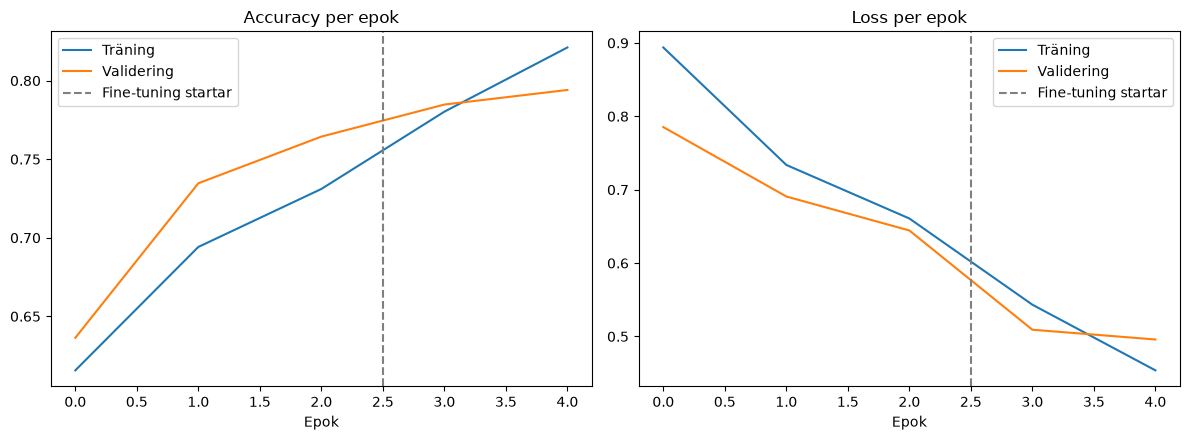

In [9]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(acc, label="Träning"); axes[0].plot(val_acc, label="Validering")
axes[0].axvline(EPOCHS_PHASE1 - 0.5, color="gray", linestyle="--", label="Fine-tuning startar")
axes[0].set_title("Accuracy per epok"); axes[0].set_xlabel("Epok"); axes[0].legend()

axes[1].plot(loss, label="Träning"); axes[1].plot(val_loss, label="Validering")
axes[1].axvline(EPOCHS_PHASE1 - 0.5, color="gray", linestyle="--", label="Fine-tuning startar")
axes[1].set_title("Loss per epok"); axes[1].set_xlabel("Epok"); axes[1].legend()

plt.tight_layout()
plt.savefig("charts/sentiment_training_curves.png", dpi=150)
plt.show()


**Vad diagrammen visar:** hela träningsförloppet i ett svep, med en streckad
lodrät linje där fine-tuningen (steg 5) tar vid. Vänster: accuracy bör vara stigande, ofta med
ett litet extra hopp precis vid den streckade linjen då fine-tuningen börjar påverka. Höger:
loss (hur "fel" modellen har) bör falla över tid. Om tränings- och valideringskurvorna följs
åt är det ett bra tecken; om de börjar gå isär (validering blir sämre medan träning fortsätter
förbättras) är det överfittning.


## Spara modellen för notebook 06 (utvärdering) och Streamlit-appen

In [10]:
model.save("models/sentiment_model.keras")
tokenizer.save_pretrained("models/sentiment_tokenizer")
print("Sparade models/sentiment_model.keras och models/sentiment_tokenizer/")


c:\Users\anoth\dev\AIkurs-statistik\airline-sentiment-transfer-learning\.venv\Lib\site-packages\transformers\generation\tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


Sparade models/sentiment_model.keras och models/sentiment_tokenizer/


**Vad output visar:** en bekräftelse att både modellen (vikter + arkitektur) och
tokenizern sparats till `./models/`. Bägge behövs i notebook 06 — modellen ensam räcker inte,
eftersom vi också måste tokenisera ny text på exakt samma sätt som under träningen.


## Sammanfattning

Modellen är tränad i två faser: först bara klassificeringshuvudet (frusen bas), sedan
fine-tuning av de två sista transformerblocken. Full utvärdering på testsetet — accuracy,
F1, confusion matrix — görs i nästa notebook, tillsammans med den andra modellen.

**Nästa steg:** öppna `05_negative_reason_classification.ipynb`.
